### Handling Missing Values Intent Dataset

In [1]:
import pandas as pd 
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

pd.set_option('display.max_columns', None)

In [2]:
dsqi = pd.read_csv('dataset_multiintent.csv', encoding='latin-1') # dsqi = dataset question intent
dsqi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  348 non-null    object
 1   Intent    348 non-null    object
dtypes: object(2)
memory usage: 5.6+ KB


In [3]:
dsqi.head()

,question,Intent
0,"Jujur, saya merasa cukup cemas sebelum datang ...",Perasaan Takut dan Kecemasan; Perasaan Sebelum...
1,"Saya merasa agak gugup, Kak. Saya tidak tahu b...",Perasaan Takut dan Kecemasan; Perasaan Sebelum...
2,"Saya merasa baik-baik saja, Kak. Awalnya saya ...",Rasa Syukur dan Apresiasi; Reaksi Terkejut dan...
3,"Saya merasa agak cemas, Kak. Tapi saya ingin m...",Perasaan Sebelum Menghadapi Kejadian
4,"Saya merasa... biasa saja, tapi kadang saya me...",Perasaan Sedih dan Kehilangan


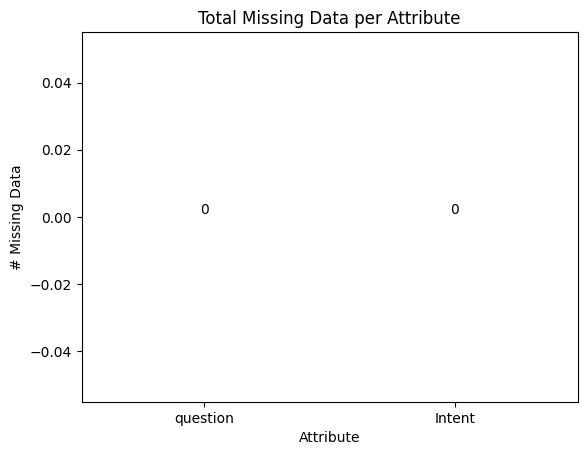

In [4]:
# Check Missing Values

df_nan = dsqi.isna().sum().reset_index().rename(columns={'index':'Column',0:'Total_NaN'}).sort_values(by='Total_NaN', ascending=False)
plt.bar(x=df_nan['Column'], height=df_nan['Total_NaN'], color='grey')
for i, v in enumerate(df_nan['Total_NaN']):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.title("Total Missing Data per Attribute")
plt.ylabel('# Missing Data')
plt.xlabel('Attribute')
plt.show()

In [5]:
# checking missing data in attribute `intent`
print(f"Total missing data: {dsqi[dsqi['Intent'].isna()].shape[0]}\n-----------------")
dsqi[dsqi['Intent'].isna()].head()

Total missing data: 0
-----------------


,question,Intent


In [6]:
# drop missing data in attribute `intent`
dsqi.dropna(subset=['Intent'], inplace=True)

In [7]:
dsqi.to_csv('dataset_multiintent.csv', index=False)

In [8]:
dsqi['Intent'].value_counts()

Intent
Perasaan Takut dan Kecemasan                                                                              37
Perasaan Sebelum Menghadapi Kejadian                                                                      30
Perasaan Percaya                                                                                          27
Perasaan Sedih dan Kehilangan                                                                             26
Perasaan Marah dan Frustasi                                                                               21
                                                                                                          ..
Perasaan Percaya ; Perasaan Sedih dan Kehilangan; Perasaan Sebelum Menghadapi Kejadian                     1
Perasaan Benci dan Jijik; Perasaan Takut dan Kecemasan; Perasaan Sebelum Menghadapi Kejadian               1
Perasaan Benci dan Jijik; Perasaan Marah dan Frustasi                                                      1
Perasaan Sed

### Handling Missing Values QnA Dataset

In [40]:
dqna = pd.read_csv('dataset_qna.csv')
dqna.head()

,question,answer,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,NaN,"Halo DNS, terima kasih sudah datang ke sesi ko...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Jujur, saya merasa cukup cemas sebelum datang ...","Tidak apa-apa, DNS. Kita bisa berbicara dengan...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,"Halo JMP, terima kasih sudah datang ke sesi ko...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Saya merasa agak gugup, Kak. Saya tidak tahu b...",Tidak perlu terburu-buru. Kita bisa berbicara ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,"Halo D, terima kasih sudah datang ke sesi kons...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
# drop kolom yang kosong
dqna = dqna.dropna(axis=1, how='all')
dqna.head()

,question,answer
0,NaN,"Halo DNS, terima kasih sudah datang ke sesi ko..."
1,"Jujur, saya merasa cukup cemas sebelum datang ...","Tidak apa-apa, DNS. Kita bisa berbicara dengan..."
2,NaN,"Halo JMP, terima kasih sudah datang ke sesi ko..."
3,"Saya merasa agak gugup, Kak. Saya tidak tahu b...",Tidak perlu terburu-buru. Kita bisa berbicara ...
4,NaN,"Halo D, terima kasih sudah datang ke sesi kons..."


In [42]:
# cari NaN di question
dqna[dqna.isnull().any(axis=1)]

,question,answer
0,NaN,"Halo DNS, terima kasih sudah datang ke sesi ko..."
2,NaN,"Halo JMP, terima kasih sudah datang ke sesi ko..."
4,NaN,"Halo D, terima kasih sudah datang ke sesi kons..."
6,NaN,"Halo RIM, terima kasih sudah datang ke sesi ko..."
8,NaN,"Halo AMK, terima kasih sudah datang ke sesi ko..."
...,...,...
994,NaN,NaN
995,NaN,NaN
996,NaN,NaN
997,NaN,NaN


In [44]:
# hapus yang memiliki NaN di kedua kolom
dqna.dropna(how='all', inplace=True)
dqna[dqna.isnull().any(axis=1)]

,question,answer
0,NaN,"Halo DNS, terima kasih sudah datang ke sesi ko..."
2,NaN,"Halo JMP, terima kasih sudah datang ke sesi ko..."
4,NaN,"Halo D, terima kasih sudah datang ke sesi kons..."
6,NaN,"Halo RIM, terima kasih sudah datang ke sesi ko..."
8,NaN,"Halo AMK, terima kasih sudah datang ke sesi ko..."
9,NaN,"Halo AH, terima kasih sudah datang ke sesi kon..."
10,NaN,"Halo CCW, terima kasih sudah datang ke sesi ko..."
12,NaN,"Halo DE, terima kasih sudah datang ke sesi kon..."
14,NaN,"Halo GB, selamat datang kembali. Saya senang k..."
16,NaN,"Halo NJ, senang bisa bertemu denganmu lagi. Ba..."


In [45]:
# Mengganti beberapa baris Nan dengan 'Halo' jika question dimulai dengan 'Halo'
idx_greeting = []
for i, row in dqna[dqna.question.isnull()].reset_index().iterrows():
  if row['answer'].startswith('Halo'):
    idx_greeting.append(row[0])

dqna.loc[idx_greeting, 'question'] = 'Halo'
dqna.iloc[idx_greeting]

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_10904\2614353079.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  idx_greeting.append(row[0])


,question,answer
0,Halo,"Halo DNS, terima kasih sudah datang ke sesi ko..."
2,Halo,"Halo JMP, terima kasih sudah datang ke sesi ko..."
4,Halo,"Halo D, terima kasih sudah datang ke sesi kons..."
6,Halo,"Halo RIM, terima kasih sudah datang ke sesi ko..."
8,Halo,"Halo AMK, terima kasih sudah datang ke sesi ko..."
9,Halo,"Halo AH, terima kasih sudah datang ke sesi kon..."
10,Halo,"Halo CCW, terima kasih sudah datang ke sesi ko..."
12,Halo,"Halo DE, terima kasih sudah datang ke sesi kon..."
14,Halo,"Halo GB, selamat datang kembali. Saya senang k..."
16,Halo,"Halo NJ, senang bisa bertemu denganmu lagi. Ba..."


In [46]:
dqna[dqna.isnull().any(axis=1)]

,question,answer
71,NaN,Apakah ada kejadian sebelumnya dalam hidupmu y...
81,NaN,Saya memahami bahwa pengalaman di masa SMP san...
164,NaN,Kamu juga sempat cerita bahwa hubungan dengan ...
169,NaN,Kemarin kamu juga menyebutkan bahwa kamu meras...
171,NaN,Kamu juga menyebutkan bahwa saat merasa stres ...
175,NaN,Kamu juga merasa takut untuk mengunggah video ...
178,NaN,Kamu menyebutkan bahwa kamu merasa trauma deng...
193,NaN,Aku juga mendengar bahwa kamu merasa ada perla...
219,NaN,Kamu juga menyebutkan kesulitan menghargai dir...
295,NaN,"Saya ingin memperkenalkan konsep 3F (Freeze, F..."


In [47]:
# Karena dataset qna digunakan untuk retrieval jawaban berdasarkan pertanyaan, baris yang NaN di kolom question dihapus agar lebih efisien
dqna.dropna(subset='question', inplace=True)
dqna[dqna.isnull().any(axis=1)]

,question,answer
361,Itu terdengar mudah. Saya akan mencobanya jika...,NaN
383,Oke... Saya akan pikirkan lagi.,NaN
385,"Baik, aku akan mencobanya.",NaN
386,"Baik, Kak. Terima kasih banyak.",NaN


In [48]:
# begitu juga dengan kolom answer
dqna.dropna(subset='answer', inplace=True)
dqna[dqna.isnull().any(axis=1)]

,question,answer


In [49]:
# simpan dataset kembali
dqna.to_csv('dataset_qna.csv')

### Handling Missing Values Tahap Dataset

In [52]:
dt = pd.read_csv('dataset_tahap.csv', encoding='latin-1')
dt.head()

,context/intent,question
0,pembukaan,"Jujur, saya merasa cukup cemas sebelum datang ..."
1,pembukaan,"Saya merasa agak gugup, Kak. Saya tidak tahu b..."
2,pembukaan,"Saya merasa baik-baik saja, Kak. Awalnya saya ..."
3,pembukaan,"Saya merasa agak cemas, Kak. Tapi saya ingin m..."
4,pembukaan,"Saya merasa... biasa saja, tapi kadang saya me..."


In [ ]:
# cari nilai NaN dalam dataset
dt[dt.isnull().any(axis=1)]

,context/intent,question
335,NaN,Journaling? Aku tidak terbiasa menulis tentang...
357,NaN,NaN
358,NaN,NaN
359,NaN,NaN
360,NaN,NaN
...,...,...
963,NaN,NaN
964,NaN,NaN
965,NaN,NaN
966,NaN,NaN


In [54]:
# hapus nilai NaN yang ada di kedua kolom
dt.dropna(how='all', inplace=True)
dt[dt.isnull().any(axis=1)]

,context/intent,question
335,NaN,Journaling? Aku tidak terbiasa menulis tentang...


In [55]:
# Hapus NaN tersisa agar efisien
dt.dropna(subset='context/intent', inplace=True)
dt[dt.isnull().any(axis=1)]

,context/intent,question


In [56]:
# kembalikan ke csv
dt.to_csv('dataset_tahap.csv')

### END